<a href="https://colab.research.google.com/github/BioProteanLabs/Tutorials/blob/main/Grading_Copy_of_DNACrystalStructure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Photo 51 - DNA Diffraction Pattern](https://worldhistory.org)

# I can't figure out how to show you Photo 51 so click the link or something.



### Prelude: Start with the Bragg Equation:

# Having seen it once during lecture, you all intuitively understand how crystals can reveal the inner structures of macromolecules, but just for review let's take another walk through.


$$n\lambda = 2d \sin\theta$$

Where:
* **$n$** is the **order of reflection** (an integer: 1, 2, 3...).
* **$\lambda$** (lambda) is the **wavelength** of the incident X-ray beam.
* **$d$** is the **interplanar spacing** (the distance between adjacent crystal lattice planes).
* **$\theta$** (theta) is the **scattering angle** (the angle between the incident beam and the lattice planes).

This formula is describing how much diffraction from a regularly spaced grating bends light. It also shows how diffraction can create patterns of interference.


### Bridging the Gap: From Bragg's Law to the Structure Factor

*How do we get from a simple geometry formula ($n\lambda = 2d\sin\theta$) to a complex continuous calculus equation?*

We need to translate from **discrete mirror planes** showing the end point of diffration to **continuous wave vectors** that give us a model of crystal structure.

---

#### Translating Bragg into Reciprocal Vectors
Bragg's Law treats crystals like a stack of mirrors separated by a distance $d$. In vector physics, we describe the incoming X-ray beam as a wave vector $\mathbf{k}_0$ and the scattered beam as $\mathbf{k}$.
*Note: I don't choose the variable letters! We just have to live with k standing for everything.*

The change in the beam's direction is the **scattering vector** $\mathbf{s}$:
$$\mathbf{s} = \mathbf{k} - \mathbf{k}_0$$

The magnitude of this scattering vector relates directly to the scattering angle $\theta$ and wavelength $\lambda$:
$$|\mathbf{s}| = \frac{2\sin\theta}{\lambda}$$

If we substitute Bragg's Law ($2\sin\theta / \lambda = n/d$) into this vector magnitude, we get:
$$|\mathbf{s}| = \frac{n}{d}$$

**Why there are discrete spots:** Bragg’s Law is satisfied only when the scattering vector $\mathbf{s}$ exactly matches a vector in the "reciprocal lattice" of the crystal. This is known as the **Laue Condition**. When this condition is met, we get regular diffraction that appears as a spot.

---

#### Accounting for Phase Shift Between Two Points
Bragg's Law assumes all scattering happens exactly on flat planes floating in space. But real molecules have electrons distributed *between* planes. Anything besides a perfect sphere is going to cause changes in diffraction intensity.

If any electron density is shifted away from the origin by a position vector $\mathbf{r}$, the X-ray wave scattering off it will travel a slightly different distance. This path length difference creates a **phase shift** ($\alpha$):

$$\alpha = 2\pi (\mathbf{s} \cdot \mathbf{r})$$

Using Euler's formula ($e^{i\alpha}$), we can represent this scattered wave mathematically as a complex exponential:
$$\text{Scattered Wave Contribution} = e^{2\pi i (\mathbf{s} \cdot \mathbf{r})}$$

---

#### Integrating the Entire Electron Cloud (The Structure Factor) based on how it changes Bragg.

Instead of counting discrete planes or perfect spheres, we know the molecules of the protein crystal are a continuous cloud of electron density that is exactly the same for every element of our crystal. Density is denoted as $\rho(\mathbf{r})$.

To find the total scattered wave at any point in space, we must add up (integrate) the scattering contributions of every tiny bit of electron density $d\mathbf{r}$, multiplied by its respective phase shift:

$$F(\mathbf{s}) = \int \rho(\mathbf{r}) e^{2\pi i \mathbf{s} \cdot \mathbf{r}} d\mathbf{r}$$

This is the **Structure Factor Equation**.

#### Summary of the Bridge
* **Bragg's Law** tells us **where** the spots can exist on the film (the grid lines allowed by the lattice spacing, $d$).
* **The Structure Factor Equation** tells us the **intensity and phase** of those spots based on how the actual electron cloud $\rho(\mathbf{r})$ is arranged within that spacing.


### 1. The Structure Factor and the Fourier Relationship
The structure factor $F(h,k,l)$, which dictates the diffraction pattern, is the Fourier Transform of the electron density $\rho(\mathbf{r})$:

$$F(h,k,l) = \int \rho(\mathbf{r}) e^{2\pi i \mathbf{s} \cdot \mathbf{r}} d\mathbf{r}$$

* **The Problem:** X-ray film only records the **intensity** of the scattered waves ($I \propto |F|^2$).
* **The HARD problem:** The **phase** information (where the wave crests and troughs are) is completely lost. Without the phase information, you cannot perform the inverse Fourier Transform to calculate the electron density $\rho(\mathbf{r})$. If you had an X-ray laser the waves would all be coherent and in the same phase, but these folks were shooting electrons at a copper plate and giving themselves cancer.


### 2. The Helical Diffraction Transform or Why we didn't solve DNA like any other crystal.

Instead of guessing a random 3D electron density function, Cochran, Crick, and Vand defined a helix in cylindrical coordinates $(r, \phi, z)$ and calculated its analytical Fourier Transform.

They discovered that the structural factor for a continuous helix natively results in **Bessel functions ($J_n$)**:

$$F(R, \Psi, \frac{n}{P}) = J_n(2\pi r R) e^{in(\Psi + \frac{\pi}{2})}$$

Where:
* **$P$** is the pitch of the helix (vertical distance of one full turn).
* **$r$** is the radius of the helix.
* **$J_n$** is the $n$-th order Bessel function.


### 3. Decoding Photo 51 with Bessel Functions
Bessel functions ($J_n$) have oscillatory properties. When plotted in reciprocal space, they naturally form an **"X" or cross-shaped pattern**.

Run the code below to look at how bessel functions

<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1905/1638115468.py:20: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Reciprocal Radius Argument ($2\pi r R$)", fontsize=12)


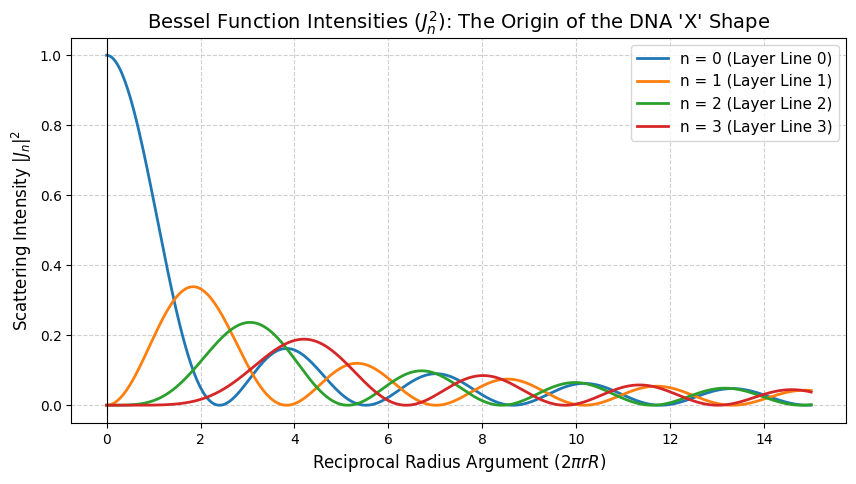

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# DNA Structural Dimensions (in Angstroms)
r_dna = 10.0      # Radius of the DNA helix (~10 Å)
pitch = 34.0      # Pitch of the helix (~34 Å)

# X-axis: Radial distance in reciprocal space (nm^-1 or Å^-1 context)
# We plot as a function of the argument (2 * pi * r * R)
x = np.linspace(0, 15, 500)

plt.figure(figsize=(10, 5))

# Plot Bessel functions for layer lines n = 0, 1, 2, 3
for n in range(4):
    plt.plot(x, jv(n, x)**2, label=f'n = {n} (Layer Line {n})', lw=2)

plt.title("Bessel Function Intensities ($J_n^2$): The Origin of the DNA 'X' Shape", fontsize=14)
plt.xlabel("Reciprocal Radius Argument ($2\pi r R$)", fontsize=12)
plt.ylabel("Scattering Intensity $|J_n|^2$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()



* **The Layer Lines ($n$):** The horizontal lines of the "X" occur at discrete intervals along the vertical axis ($Z$). This is a direct reciprocal application of Bragg's Law:
  $$Z = \frac{n}{P}$$
  By measuring the spacing between layer lines, Franklin determined the **helix pitch ($P$) was $\sim 34$ Å**.


* **The Outer Meriodional Reflection:** At the very top and bottom of the film, a heavy diamond-shaped smear appears on the 10th layer line. Applying Bragg's spacing:
  $$d = \frac{P}{10} = \frac{34\text{ Å}}{10} = 3.4\text{ Å}$$
  This proved that the individual base pairs were stacked flat on top of each other every **$3.4$ Å**.

* **The "Missing" 4th Layer Line:** The 4th layer line in Photo 51 is conspicuously absent. CCV theory dictates that if there are two intersecting periodicities (like two sugar-phosphate backbones), interference will cancel out certain Bessel functions.

Let's look closer at that important clue.

# Bezel Function for the Double Helix

<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1905/2342423223.py:35: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Reciprocal Radius Argument ($2\pi r R$)", fontsize=11)


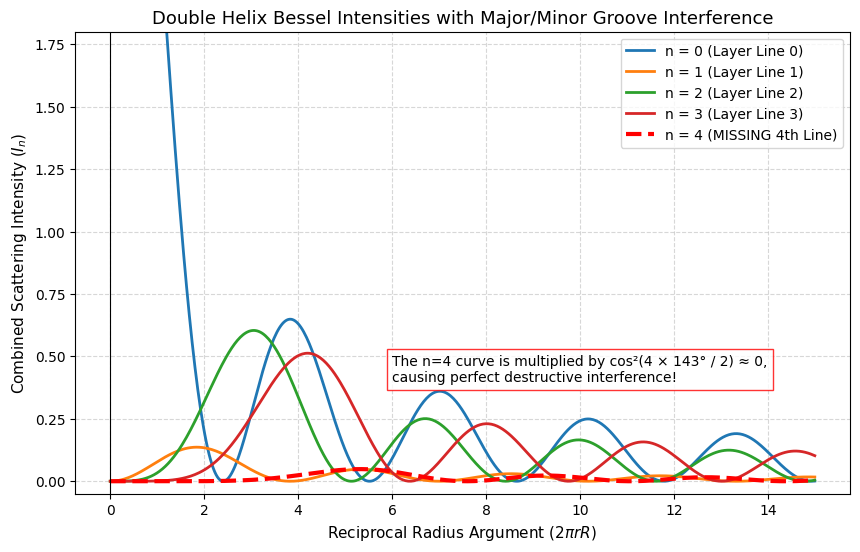

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# DNA Structural Dimensions
r_dna = 10.0      # Radius of the DNA helix (~10 Å)

# Angular offset between the two sugar-phosphate backbones (in radians)
# 143 degrees creates the characteristic major and minor grooves of B-DNA
delta_phi = np.radians(143.0)

# X-axis: Radial distance in reciprocal space
x = np.linspace(0, 15, 500)

plt.figure(figsize=(10, 6))

# Plot the interfered Bessel functions for layer lines n = 0, 1, 2, 3, 4
for n in range(5):
    # 1. Single helix component
    single_helix_intensity = jv(n, x)**2

    # 2. Double helix interference factor
    interference_factor = np.cos((n * delta_phi) / 2.0)**2

    # 3. Combined total intensity
    total_intensity = 4 * single_helix_intensity * interference_factor

    # Set a distinct style for the 4th layer line so students notice it flatlining
    if n == 4:
        plt.plot(x, total_intensity, label=f'n = {n} (MISSING 4th Line)', color='red', lw=3, linestyle='--')
    else:
        plt.plot(x, total_intensity, label=f'n = {n} (Layer Line {n})', lw=2)

plt.title("Double Helix Bessel Intensities with Major/Minor Groove Interference", fontsize=13)
plt.xlabel("Reciprocal Radius Argument ($2\pi r R$)", fontsize=11)
plt.ylabel("Combined Scattering Intensity ($I_n$)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')
plt.axvline(x=0, color='black', linewidth=0.8)

# Add an explanatory text box directly on the chart for the lecture
plt.text(6, 0.4, "The n=4 curve is multiplied by cos²(4 × 143° / 2) ≈ 0,\ncausing perfect destructive interference!",
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.ylim(-0.05, 1.8)
plt.show()



### The Mathematics of Double-Helix Interference

When X-rays scatter off a **double helix** (two identical sugar-phosphate backbones sharing the same axis), the total scattering intensity is not simply doubled. Instead, the waves from both strands interfere with each other.

The physical formula for the scattering intensity ($I_n$) on the $n$-th layer line is given by:

$$I_n(R) = 4 \cdot J_n^2(2\pi r R) \cdot \cos^2\left(\frac{n \cdot \Delta\phi}{2}\right)$$

#### Parameter Breakdown:
* **$J_n^2(2\pi r R)$**: The intrinsic scattering intensity of a **single** isolated continuous helix of radius $r$ at reciprocal radius $R$.
* **$\Delta\phi$**: The **angular offset** (in radians) between the two strands looking down the helical axis.
* **$\cos^2\left(\frac{n \cdot \Delta\phi}{2}\right)$**: The **interference factor**. This term acts as a mathematical filter that scales, suppresses, or completely eliminates specific layer lines based purely on the structural geometry of the grooves.

#### Why the 4th Layer Line Vanishes in B-DNA:
In B-DNA, the two backbones are not spaced symmetrically ($180^\circ$ apart). Instead, they are shifted to create the unequal **major and minor grooves**, yielding an angular offset of:

$$\Delta\phi \approx 143.4^\circ \quad \left(\text{or } \frac{3}{8} \text{ of a full } 360^\circ \text{ turn}\right)$$

Plugging $n = 4$ and $\Delta\phi = 143.4^\circ$ into the interference factor yields:

$$\cos^2\left(\frac{4 \cdot 143.4^\circ}{2}\right) = \cos^2(286.8^\circ) \approx \cos^2\left(\frac{3\pi}{2}\right) = 0$$

Because this term drops to exactly **0**, the 4th layer line suffers perfect destructive interference and completely disappears from **Photo 51**.



# Further reading on the double helix.
https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/05%3A_Diffraction_Phenomena/5.04%3A_Simulating_DNA's_Diffraction_Pattern

# Simulated DNA Diffraction Pattern.

Let's see what happens when you translate those stacked functions on each other. You might guess it's going to look like Photo 51 but sadly we will never know because of copyright oh well!

<>:49: SyntaxWarning: invalid escape sequence '\A'
<>:50: SyntaxWarning: invalid escape sequence '\A'
<>:49: SyntaxWarning: invalid escape sequence '\A'
<>:50: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1905/817240855.py:49: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Reciprocal Radius $R$ ($\AA^{-1}$)", fontsize=12)
/tmp/ipykernel_1905/817240855.py:50: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel("Reciprocal Height $Z$ ($\AA^{-1}$) [Layer Lines]", fontsize=12)


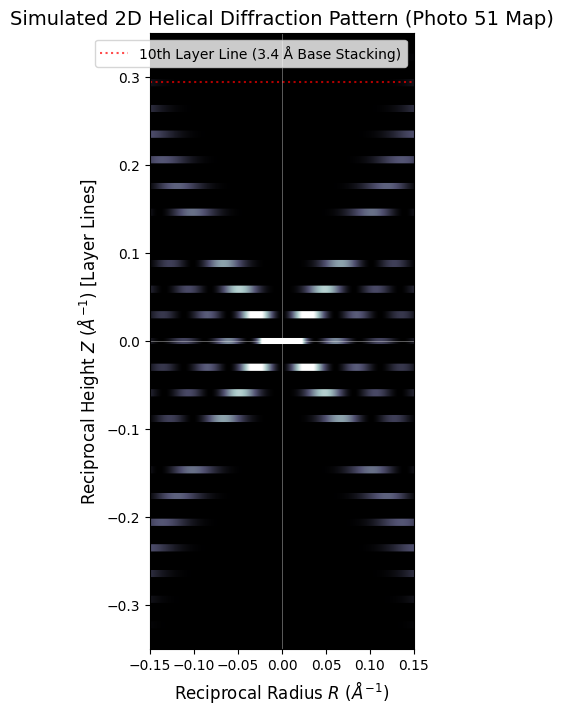

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# DNA Structural Dimensions (in Angstroms)
r_dna = 10.0      # Radius (~10 Å)
pitch = 34.0      # Pitch (~34 Å)
max_layer = 11    # Display up to the 11th layer line (to see the 10th stack)

# Create a grid for our virtual X-ray film
# X axis: Reciprocal radius (R), Y axis: Reciprocal height (Z)
R_vals = np.linspace(-0.15, 0.15, 600)  # in Å^-1
Z_vals = np.linspace(-0.35, 0.35, 600)  # in Å^-1
R, Z = np.meshgrid(R_vals, Z_vals)

# Initialize the diffraction pattern intensity grid
diffraction_pattern = np.zeros_like(R)

# Approximate a small tolerance band around each discrete layer line
layer_line_thickness = 0.004

# Loop through each layer line 'n' (both positive and negative reflections)
for n in range(-max_layer, max_layer + 1):
    # Reciprocal Bragg Condition for the helix layer line position
    Z_target = n / pitch

    # Locate where the grid matches this specific layer line
    mask = np.abs(Z - Z_target) < layer_line_thickness

    if np.any(mask):
        # Calculate the mathematical argument for the Bessel function: 2 * pi * r * R
        bessel_arg = 2 * np.pi * r_dna * np.abs(R[mask])

        # Omit the 4th layer line to simulate double-helix interference
        # (Comment out this 'if' block if you want to show a single helix first!)
        if abs(n) == 4:
            intensities = 0
        else:
            intensities = jv(abs(n), bessel_arg)**2

        diffraction_pattern[mask] = intensities

# Plot the simulated Photo 51
plt.figure(figsize=(8, 8))
plt.imshow(diffraction_pattern, extent=[R_vals.min(), R_vals.max(), Z_vals.min(), Z_vals.max()],
           cmap='bone', origin='lower', vmax=0.3)

plt.title("Simulated 2D Helical Diffraction Pattern (Photo 51 Map)", fontsize=14)
plt.xlabel("Reciprocal Radius $R$ ($\AA^{-1}$)", fontsize=12)
plt.ylabel("Reciprocal Height $Z$ ($\AA^{-1}$) [Layer Lines]", fontsize=12)

# Add visual markers for the lecture points
plt.axhline(10/34, color='red', linestyle=':', alpha=0.7, label='10th Layer Line (3.4 Å Base Stacking)')
plt.axhline(0, color='white', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='white', linewidth=0.5, alpha=0.5)
plt.legend(loc='upper right')

plt.show()


# Now for your Quiz question!
# **Simulate Z DNA and submit a picture of your diffraction pattern**

Don't worry, I made it easy for you.

• **Change the Pitch Slider:** Watch how increasing the pitch compresses the vertical distance between the layer lines (a classic reciprocal relationship).

• **Change the Radius Slider:** Watch how increasing the radius shrinks the arm span of the "X" cross pattern.

• **Toggle the Handedness:** Why would you want to do that? I'm really just handing this one to you.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def simulate_3d_helical_diffraction(r_dna, pitch, handedness, num_atoms=60):
    """
    Simulates the 2D diffraction pattern by taking the explicit Fourier Transform
    of a 3D helical arrangement of scattering points to capture handedness.
    """
    # 1. Generate 3D coordinates for a helix based on parameters
    t = np.linspace(0, 4 * np.pi, num_atoms)  # ~2 full turns

    # Handedness determines the sign of the y-coordinate rotation relative to x
    if handedness == 'Right-Handed':
        x = r_dna * np.cos(t)
        y = r_dna * np.sin(t)
    else:  # Left-Handed
        x = r_dna * np.cos(t)
        y = -r_dna * np.sin(t)  # Invert rotation to change screw direction

    z = (pitch * t) / (2 * np.pi)

    # Center the coordinates around z
    z -= np.mean(z)

    # 2. Define the reciprocal space grid (virtual X-ray film)
    R_vals = np.linspace(-0.25, 0.25, 200) # Reciprocal X (Å^-1)
    Z_vals = np.linspace(-0.25, 0.25, 200) # Reciprocal Z (Å^-1)
    R_grid, Z_grid = np.meshgrid(R_vals, Z_vals)

    # Initialize intensity array
    diffraction_intensity = np.zeros_like(R_grid)

    # 3. Explicitly compute the Discrete Fourier Transform for each pixel on the film
    # F(R, Z) = Sum( exp( -2 * pi * i * (R*x_j + Z*z_j) ) )
    # To introduce real structural skewing, we simulate a tilted fiber orientation
    for i in range(R_grid.shape[0]):
        for j in range(R_grid.shape[1]):
            qx = 2 * np.pi * R_grid[i, j]
            qz = 2 * np.pi * Z_grid[i, j]

            # Phase factor summation over all discrete atoms
            # Adding a tiny y-axis component breaks the 2D flat symmetry
            # to let handedness manifest visually on a 2D projection
            phase = qx * (x + 0.15 * y) + qz * z
            fourier_sum = np.sum(np.exp(-1j * phase))

            diffraction_intensity[i, j] = np.abs(fourier_sum)**2

    # 4. Plotting
    plt.figure(figsize=(7, 7))
    plt.imshow(diffraction_intensity, extent=[R_vals.min(), R_vals.max(), Z_vals.min(), Z_vals.max()],
               cmap='magma', origin='lower')

    plt.title(f"3D Helical Fourier Transform ({handedness})\nRadius = {r_dna} Å | Pitch = {pitch} Å", fontsize=12)
    plt.xlabel("Reciprocal Radius $R$ ($\AA^{-1}$)", fontsize=11)
    plt.ylabel("Reciprocal Height $Z$ ($\AA^{-1}$)", fontsize=11)
    plt.axhline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.axvline(0, color='white', linewidth=0.5, alpha=0.3)
    plt.show()

# Interactive controls layout
interact(
    simulate_3d_helical_diffraction,
    r_dna = widgets.FloatSlider(value=10.0, min=5.0, max=18.0, step=0.5, description='Radius ($r$ Å):'),
    pitch = widgets.FloatSlider(value=34.0, min=20.0, max=50.0, step=1.0, description='Pitch ($P$ Å):'),
    handedness = widgets.Dropdown(options=['Right-Handed', 'Left-Handed'], value='Right-Handed', description='Handedness:'),
    num_atoms = widgets.IntSlider(value=80, min=20, max=150, step=5, description='Atom Density:')
);


<>:57: SyntaxWarning: invalid escape sequence '\A'
<>:58: SyntaxWarning: invalid escape sequence '\A'
<>:57: SyntaxWarning: invalid escape sequence '\A'
<>:58: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1905/216893249.py:57: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Reciprocal Radius $R$ ($\AA^{-1}$)", fontsize=11)
/tmp/ipykernel_1905/216893249.py:58: SyntaxWarning: invalid escape sequence '\A'
  plt.ylabel("Reciprocal Height $Z$ ($\AA^{-1}$)", fontsize=11)


interactive(children=(FloatSlider(value=10.0, description='Radius ($r$ Å):', max=18.0, min=5.0, step=0.5), Flo…

### 🧠 Lecture Check: Modeling Z-DNA Geometry

Using the interactive diffraction simulation tool above, determine how the physical parameters shift when visualizing **Z-DNA** instead of standard **B-DNA**.

**Question:** Which combination of parameters accurately mimics the physical structure and 2D diffraction transform footprint of Z-DNA?

* **A)** Radius = 12.0 Å, Pitch = 28.0 Å, Right-Handed
* **B)** Radius = 10.0 Å, Pitch = 34.0 Å, Right-Handed
* **C)** Radius = 9.0 Å, Pitch = 45.0 Å, Left-Handed
* **D)** Radius = 9.0 Å, Pitch = 45.0 Å, Right-Handed

***

**Correct Answer:** **C**

**Lecture Explanation:**
1. **Narrower Shape:** Z-DNA has a smaller structural radius (~9 Å).
2. **Elongated Stretch:** Its vertical pitch is significantly longer (~45 Å), which compresses the vertical layer lines in reciprocal space.
3. **Chirality:** It is uniquely **Left-Handed**, which tilts the asymmetrical diffraction streaks in the opposite direction compared to B-DNA.
